# Preprocessing Discover Graph text data

In [74]:
from neo4j import GraphDatabase, basic_auth
import pandas as pd
import numpy as np
import os
import json
import collections
import sklearn
import stellargraph as sg
import nltk
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [75]:
import networkx as nx
import pandas as pd
import numpy as np
import os
import tensorflow as tf


import stellargraph as sg
from stellargraph.mapper import FullBatchNodeGenerator
from stellargraph.layer import GAT

from tensorflow.keras import layers, optimizers, losses, metrics, Model
from sklearn import preprocessing, feature_extraction, model_selection
from stellargraph import datasets
from IPython.display import display, HTML
import matplotlib.pyplot as plt

nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/jpmc/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [76]:
driver = GraphDatabase.driver( "bolt://localhost:7687",  auth=basic_auth("neo4j", "nindoo123"))

# Creating StellarGraph

### Puxando Edges

In [77]:
pulling_query = """\
            MATCH (a)-->(b)
            WHERE EXISTS (a.label) AND EXISTS (b.label)
            RETURN ID(a) AS source, ID(b) AS target
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    edges_db = pd.DataFrame([dict(row) for row in result])
print(edges_db.shape)
edges_db.head()

(3561, 2)


,source,target
0,0,22
1,0,21
2,0,20
3,1,318
4,1,2


### puxando labels

In [78]:
pulling_query = """\
            MATCH (a)
            WHERE EXISTS (a.label)
            RETURN ID(a) AS source, a.label AS subject
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    label_db = pd.DataFrame([dict(row) for row in result])
labels = pd.Series(data =label_db['subject'].values, index = label_db['source'].values)
print(labels.shape)
labels.head()

(1301,)


0    Programming
1    Programming
2    Programming
3    Programming
4         Design
dtype: object

### Criando grafo

In [79]:
graph = sg.StellarGraph(edges =  edges_db)
print(graph.info())

StellarGraph: Undirected multigraph
 Nodes: 1292, Edges: 3561

 Node types:
  default: [1292]
    Features: none
    Edge types: default-default->default

 Edge types:
    default-default->default: [3561]
        Weights: all 1 (default)
        Features: none


In [80]:

walk_length = 100  # maximum/ length of a random walk to use throughout this noteboo

In [81]:
rw = sg.data.BiasedRandomWalk(graph)
weighted_walks = rw.run(
    nodes=graph.nodes(),  # root nodes
    length=walk_length,  # maximum length of a random walk
    n=10,  # number of random walks per root node
    p=0.5,  # Defines (unormalised) probability, 1/p, of returning to source node
    q=0.5,  # Defines (unormalised) probability, 1/q, for moving away from source node
    weighted=True,  # for weighted random walks
    seed=42,  # random seed fixed for reproducibility
)
print("Number of random walks: {}".format(len(weighted_walks)))

Number of random walks: 12920


In [82]:
string_walks = [[str(n) for n in walk] for walk in weighted_walks]

In [83]:
from gensim.models import Word2Vec
weighted_model = Word2Vec(
    string_walks, size=128, window=5, min_count=0, sg=1, workers=1, iter=1
)

### Embeddings

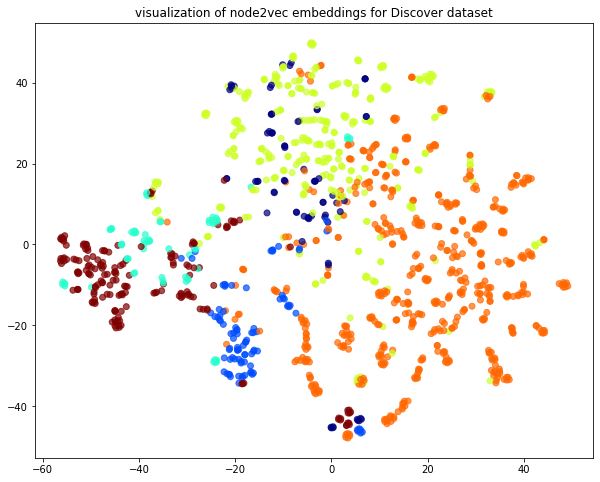

In [85]:
tsne = TSNE(n_components=2, random_state=42)
weighted_node_embeddings_2d = tsne.fit_transform(weighted_node_embeddings)

# draw the points
alpha = 0.7

plt.figure(figsize=(10, 8))
plt.scatter(
    weighted_node_embeddings_2d[:, 0],
    weighted_node_embeddings_2d[:, 1],
    c=node_targets.cat.codes,
    cmap="jet",
    alpha=0.7,
)
plt.title(
    "visualization of node2vec embeddings for Discover dataset")
plt.show()

In [84]:
# Retrieve node embeddings and corresponding subjects
node_ids = weighted_model.wv.index2word  # list of node IDs
weighted_node_embeddings = (
    weighted_model.wv.vectors
)  # numpy.ndarray of size number of nodes times embeddings dimensionality
# the gensim ordering may not match the StellarGraph one, so rearrange
int_ids = [int(node) for node in node_ids]
node_targets = labels.loc[int_ids].astype("category")


### Adicionando ao neo4j

In [86]:
pulling_query = """\
            MATCH (a)
            WHERE  ID(a) = $id
            SET a.embedding = $emb
            """
with driver.session() as sess:
    for node in int_ids:
        emb = map(float,list(weighted_model.wv[str(node)]))
        sess.run(pulling_query,{"id":node,"emb":emb})

### Retornando recomendações via python

In [87]:

final_query = """
MATCH (a:Blog),(b:Blog)
WHERE ID(a) = 1055 AND ID(a) <> ID(b) AND EXISTS (b.embedding)
RETURN DISTINCT a.title AS CLICK,a.label as FONTE, b.title AS RECOMENDACAO, b.label AS AREA, gds.alpha.similarity.cosine(a.embedding,b.embedding) AS SIMILARIDADE ORDER BY SIMILARIDADE DESC
"""
with driver.session() as sess:
    result = sess.run(final_query)
    df_final = pd.DataFrame([dict(row) for row in result])
print("----POSSÍVEIS LINKS----")
print(df_final)

----POSSÍVEIS LINKS----
                                                 CLICK      FONTE  \
0    Five steps parents can take to help kids overc...  Education   
1    Five steps parents can take to help kids overc...  Education   
2    Five steps parents can take to help kids overc...  Education   
3    Five steps parents can take to help kids overc...  Education   
4    Five steps parents can take to help kids overc...  Education   
..                                                 ...        ...   
424  Five steps parents can take to help kids overc...  Education   
425  Five steps parents can take to help kids overc...  Education   
426  Five steps parents can take to help kids overc...  Education   
427  Five steps parents can take to help kids overc...  Education   
428  Five steps parents can take to help kids overc...  Education   

                                          RECOMENDACAO         AREA  \
0                         Penn State Employees Revolt!    Education   
1    